# Figure Generation from Excel Results

This notebook generates **Figures 4, 5, and 6** directly from the consolidated Excel results file,
without requiring a live Brightway2 / ecoinvent database connection.

**Data source:** `V30 - Comparative Results.xlsx`

| Figure | Sheet | Chart type |
|--------|-------|------------|
| 4 | `NMC_results` | Faceted line plot (small multiples) |
| 5 | `Results_NMC111` | Heatmap faceted by SSP |
| 6 | `Results_filtered` | Heatmap grid (process × impact category) |

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
EXCEL_FILE = Path("V30 - Comparative Results.xlsx")   # adjust if needed
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Colour palette (colorblind-safe) ───────────────────────────────────────
SSP_COLORS = {
    "SSP1": "#1f77b4",   # blue
    "SSP2": "#ff7f0e",   # orange
    "SSP5": "#2ca02c",   # green
}

# ── Global matplotlib style ────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 150,
})

---
## 1. Load and parse data

### 1.1  NMC_results → Figure 4  (includes swap fix)

In [2]:
# Row 0 contains full method-name strings (metadata); actual data starts at row 1.
df_nmc_raw = pd.read_excel(EXCEL_FILE, sheet_name="NMC_results", header=0)
df_nmc = df_nmc_raw.iloc[1:].copy().reset_index(drop=True)

# All 10 impact categories influenced by VSI foreground changes
VSI_AFFECTED = ["FETPinf", "GWP100", "FEP", "HTPinf",
                "METPinf", "MEP", "PMFP", "POFP", "TAP100", "TETPinf"]

UNITS = {
    "GWP100":  "kg CO\u2082-eq",
    "FETPinf": "kg 1,4-DCB eq",
    "FEP":     "kg P-eq",
    "HTPinf":  "kg 1,4-DCB eq",
    "METPinf": "kg 1,4-DCB eq",
    "MEP":     "kg N-eq",
    "PMFP":    "kg PM\u2082.\u2085-eq",
    "POFP":    "kg NMVOC-eq",
    "TAP100":  "kg SO\u2082-eq",
    "TETPinf": "kg 1,4-DCB eq",
}

df_fig4 = df_nmc[["IAM", "Scenario", "Year"] + VSI_AFFECTED].copy()
df_fig4["Year"]     = df_fig4["Year"].astype(float).astype(int)
df_fig4["IAM"]      = df_fig4["IAM"].astype(str)
df_fig4["Scenario"] = df_fig4["Scenario"].astype(str)
df_fig4[VSI_AFFECTED] = df_fig4[VSI_AFFECTED].apply(pd.to_numeric, errors="coerce")

# ── Sanity check: VSI delta should grow monotonically 2025 → 2040 ─────────
base = df_fig4[df_fig4["Scenario"] == "Base"].set_index(["IAM", "Year"])[VSI_AFFECTED]
vsi  = df_fig4[df_fig4["Scenario"] == "VSI"].set_index(["IAM", "Year"])[VSI_AFFECTED]
delta_abs = (vsi - base).abs()
avg = delta_abs.groupby("Year").mean()

print("Absolute |VSI - Base| averaged across SSPs (each column should increase 2025→2040):")
print(avg.round(6).to_string())
print()

mono = (avg.loc[2030] >= avg.loc[2025]) & \
       (avg.loc[2035] >= avg.loc[2030]) & \
       (avg.loc[2040] >= avg.loc[2035])
print("Monotonically increasing? (all should be True):")
for cat in VSI_AFFECTED:
    flag = "✓" if mono[cat] else "✗  <-- check this"
    print(f"  {cat:<10} {flag}")


Absolute |VSI - Base| averaged across SSPs (each column should increase 2025→2040):
       FETPinf    GWP100       FEP    HTPinf   METPinf       MEP      PMFP      POFP    TAP100   TETPinf
Year                                                                                                    
2025  0.000007  0.000430  0.000000  0.000230  0.000009  0.000001  0.000001  0.000001  0.000001  0.000002
2030  0.012181  0.006446  0.000110  0.029293  0.003186  0.001150  0.001699  0.000562  0.005174  0.000049
2035  0.046686  0.045824  0.000423  0.099311  0.011326  0.004268  0.006189  0.002095  0.018658  0.000155
2040  0.062046  0.055480  0.000533  0.739192  0.018165  0.005426  0.008051  0.002715  0.024480  0.000258

Monotonically increasing? (all should be True):
  FETPinf    ✓
  GWP100     ✓
  FEP        ✓
  HTPinf     ✓
  METPinf    ✓
  MEP        ✓
  PMFP       ✓
  POFP       ✓
  TAP100     ✓
  TETPinf    ✓


### 1.2  Results_NMC111 → Figure 5

In [3]:
df5_raw = pd.read_excel(EXCEL_FILE, sheet_name="Results_NMC111", header=0)
df5 = df5_raw.iloc[1:].copy().reset_index(drop=True)
df5.columns = ["IAM", "Impact", 2025, 2030, 2035, 2040]
df5["IAM"] = df5["IAM"].ffill()
for yr in [2025, 2030, 2035, 2040]:
    df5[yr] = pd.to_numeric(df5[yr], errors="coerce") * 100

# Order categories from most to least mitigation (by 2040 average across SSPs)
cat_order = df5.groupby("Impact")[2040].mean().sort_values().index.tolist()
print("Category order (most mitigated → least):", cat_order)

Category order (most mitigated → least): ['MEP', 'TAP100', 'PMFP', 'FEP', 'POFP', 'HTPinf', 'FETPinf', 'TETPinf', 'METPinf', 'GWP100']


### 1.3  Results_filtered → Figure 6

In [4]:
df6_raw = pd.read_excel(EXCEL_FILE, sheet_name="Results_filtered", header=0)

def parse_filtered_table(df, col_activity, col_impact_abbrev, col_d1, col_d2, col_d3):
    data = df.iloc[2:].copy()
    data[col_activity] = data[col_activity].ffill()
    data = data[data[col_impact_abbrev].notna() &
                (data[col_impact_abbrev].astype(str).str.len() > 1)].copy()
    d1 = pd.to_numeric(data[col_d1], errors="coerce")
    d2 = pd.to_numeric(data[col_d2], errors="coerce")
    d3 = pd.to_numeric(data[col_d3], errors="coerce")
    # Exclude header rows ('Δ' string → NaN) and all-zero rows (no VSI effect)
    mask = d1.notna() & ~((d1 == 0) & (d2 == 0) & (d3 == 0))
    data = data[mask].copy()
    return pd.DataFrame({
        "activity": data[col_activity].values,
        "impact":   data[col_impact_abbrev].values,
        "SSP1":     pd.to_numeric(data[col_d1], errors="coerce").values * 100,
        "SSP2":     pd.to_numeric(data[col_d2], errors="coerce").values * 100,
        "SSP5":     pd.to_numeric(data[col_d3], errors="coerce").values * 100,
    }).reset_index(drop=True)

df6_left  = parse_filtered_table(df6_raw,
    "Unnamed: 1",  "Unnamed: 5",  "Unnamed: 8",  "Unnamed: 11", "Unnamed: 14")
df6_right = parse_filtered_table(df6_raw,
    "Unnamed: 16", "Unnamed: 20", "Unnamed: 23", "Unnamed: 26", "Unnamed: 29")
df6_all = pd.concat([df6_left, df6_right], ignore_index=True)

SUBSYSTEM_MAP = {
    "platinum group metal mine operation, ore with high palladium content (RU)": "Nickel / PGM",
    "platinum group metal, mine and concentration operations (ZA)":               "Nickel / PGM",
    "nickel mine operation and benefication to nickel concentrate, 7% Ni (CN)":  "Nickel / PGM",
    "smelting and refining of nickel concentrate, 16% Ni (GLO)":                  "Nickel / PGM",
    "smelting and refining of nickel concentrate, 7% Ni (CN)":                    "Nickel / PGM",
    "cobalt production (GLO)":                                                     "Nickel / PGM",
    "spodumene production (AU)":                                                   "Lithium",
    "spodumene production (RoW)":                                                  "Lithium",
    "lithium carbonate production, from spodumene (CN)":                          "Lithium",
    "manganese(III) oxide production (RoW":                                        "Manganese",
    "manganese dioxide production (GLO)":                                          "Manganese",
    "manganese sulfate production (GLO)":                                          "Manganese",
}
SHORT_NAME_MAP = {
    "platinum group metal mine operation, ore with high palladium content (RU)": "PGM mine (RU)",
    "platinum group metal, mine and concentration operations (ZA)":               "PGM mine+conc (ZA)",
    "nickel mine operation and benefication to nickel concentrate, 7% Ni (CN)":  "Ni mine (CN)",
    "smelting and refining of nickel concentrate, 16% Ni (GLO)":                  "Ni smelt 16% (GLO)",
    "smelting and refining of nickel concentrate, 7% Ni (CN)":                    "Ni smelt 7% (CN)",
    "cobalt production (GLO)":                                                     "Co prod (GLO)",
    "spodumene production (AU)":                                                   "Spodumene (AU)",
    "spodumene production (RoW)":                                                  "Spodumene (RoW)",
    "lithium carbonate production, from spodumene (CN)":                          "Li\u2082CO\u2083 (CN)",
    "manganese(III) oxide production (RoW":                                        "Mn(III) oxide (RoW)",
    "manganese dioxide production (GLO)":                                          "MnO\u2082 (GLO)",
    "manganese sulfate production (GLO)":                                          "MnSO\u2084 (GLO)",
}

df6_all["subsystem"]     = df6_all["activity"].map(SUBSYSTEM_MAP)
df6_all["activity_short"] = df6_all["activity"].map(SHORT_NAME_MAP)

# Fallback: fuzzy-assign any remaining unmapped rows by keyword
for act in df6_all[df6_all["subsystem"].isna()]["activity"].unique():
    if "manganese" in str(act).lower():
        df6_all.loc[df6_all["activity"] == act, "subsystem"]      = "Manganese"
        df6_all.loc[df6_all["activity"] == act, "activity_short"] = str(act)[:22]

print("Subsystem row counts:", df6_all["subsystem"].value_counts().to_dict())

Subsystem row counts: {'Nickel / PGM': 56, 'Manganese': 10, 'Lithium': 9}


---
## 2. Figure 4: Absolute LCA scores: faceted line plot

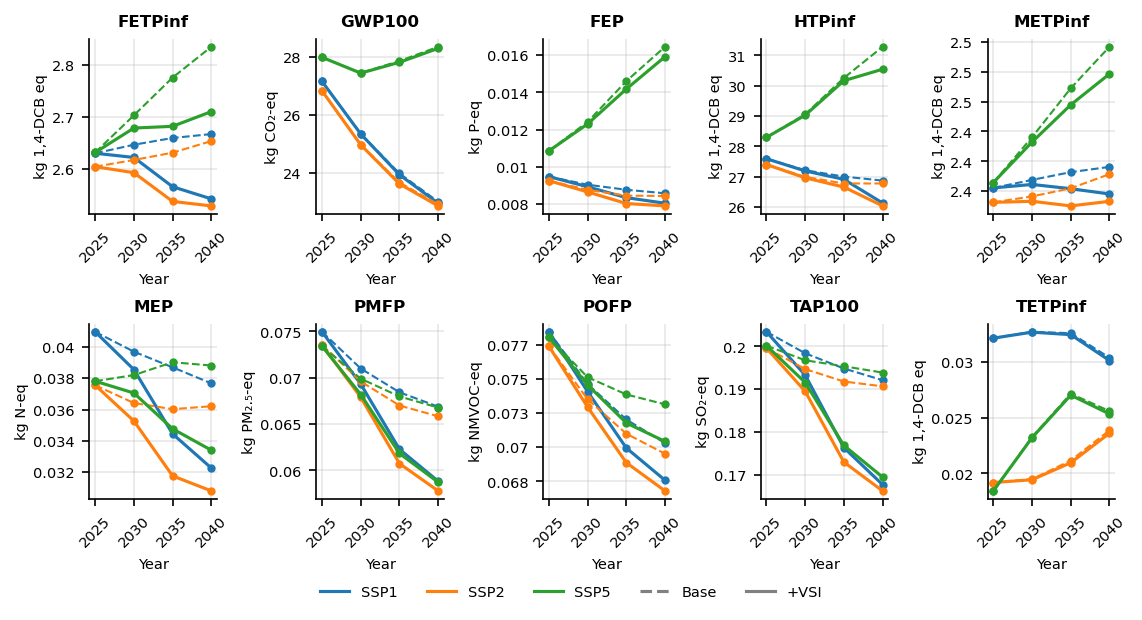

Figure 4 saved.


In [13]:
YEARS = [2025, 2030, 2035, 2040]
SSPS  = ["SSP1", "SSP2", "SSP5"]

fig, axes = plt.subplots(2, 5, figsize=(7.5, 3.8), constrained_layout=True)

for idx, cat in enumerate(VSI_AFFECTED):
    ax = axes.flatten()[idx]
    for ssp in SSPS:
        for scen, ls, lw in [("Base", "--", 1.0), ("VSI", "-", 1.5)]:
            sub = df_fig4[(df_fig4["IAM"] == ssp) & (df_fig4["Scenario"] == scen)]
            sub = sub.sort_values("Year")
            ax.plot(sub["Year"], sub[cat],
                    color=SSP_COLORS[ssp], linestyle=ls, linewidth=lw,
                    marker="o", markersize=3)
    ax.set_title(cat, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel(UNITS.get(cat, ""), labelpad=2)
    ax.set_xticks(YEARS)
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))

legend_elements = [
    Line2D([0], [0], color=SSP_COLORS["SSP1"], lw=1.5, label="SSP1"),
    Line2D([0], [0], color=SSP_COLORS["SSP2"], lw=1.5, label="SSP2"),
    Line2D([0], [0], color=SSP_COLORS["SSP5"], lw=1.5, label="SSP5"),
    Line2D([0], [0], color="grey", lw=1.5, linestyle="--", label="Base"),
    Line2D([0], [0], color="grey", lw=1.5, linestyle="-",  label="+VSI"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.06), frameon=False)
'''
fig.suptitle(
    "Absolute LCA scores for NMC111 oxide production (1 kg)\n"
    "per impact category, 2025 to 2040, Base vs +VSI",
    fontsize=8, y=1.06,
)
'''
fig.savefig(OUTPUT_DIR / "Figure4_absolute_scores.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "Figure4_absolute_scores.pdf",          bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

---
## 3. Figure 5: Relative Δ% from VSI: heatmap faceted by SSP

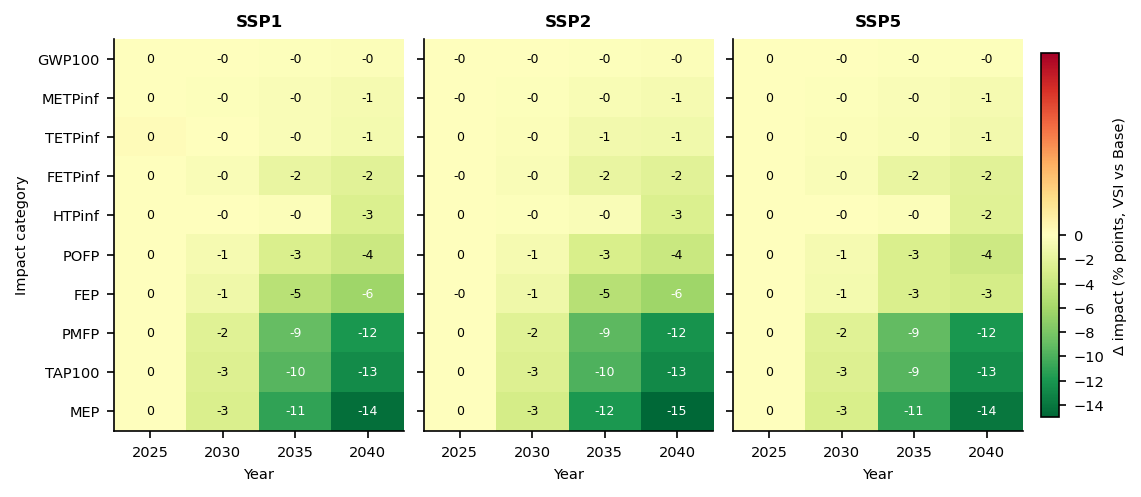

Figure 5 saved.


In [16]:
YEAR_COLS = [2025, 2030, 2035, 2040]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.2), constrained_layout=True)

vmax = df5[YEAR_COLS].abs().max().max()
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax * 0.05)
cmap = "RdYlGn_r"  # red = burden increase, green = mitigation

for ax, ssp in zip(axes, ["SSP1", "SSP2", "SSP5"]):
    sub = df5[df5["IAM"] == ssp].set_index("Impact")[YEAR_COLS]
    sub = sub.reindex(cat_order[::-1])  # most mitigated at top
    im  = ax.imshow(sub.values.astype(float), aspect="auto", cmap=cmap, norm=norm)
    ax.grid(False) 

    for r in range(sub.shape[0]):
        for c in range(sub.shape[1]):
            val = sub.values[r, c]
            if not np.isnan(val):
                txt_color = "white" if abs(val) > vmax * 0.4 else "black"
                ax.text(c, r, f"{val:.0f}", ha="center", va="center",
                        fontsize=6, color=txt_color)

    ax.set_xticks(range(len(YEAR_COLS)))
    ax.set_xticklabels(YEAR_COLS)
    ax.set_yticks(range(len(cat_order)))
    ax.set_yticklabels(cat_order[::-1] if ax == axes[0] else [])
    ax.set_title(ssp, fontweight="bold")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Impact category")
cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("\u0394 impact (% points, VSI vs Base)", fontsize=7)
'''
fig.suptitle(
    "Relative impact change from VSI (\u0394%) for NMC111 oxide\n"
    "Negative values indicate mitigation; zero values omitted",
    fontsize=8,
)
'''
fig.savefig(OUTPUT_DIR / "Figure5_heatmap_VSI_delta.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "Figure5_heatmap_VSI_delta.pdf",          bbox_inches="tight")
plt.show()
print("Figure 5 saved.")

---
## 4. Figure 6: Process-level VSI mitigation: diverging bars by subsystem

In [7]:
# ── Shared setup for all Figure 6 options ─────────────────────────────────
SSP_COLORS  = {"SSP1": "#1f77b4", "SSP2": "#ff7f0e", "SSP5": "#2ca02c"}
SSP_MARKERS = {"SSP1": "o",       "SSP2": "s",       "SSP5": "^"}

# Activity display order (Nickel/PGM → Lithium → Manganese)
ACT_ORDER = [
    "PGM mine (RU)", "PGM mine+conc (ZA)", "Ni mine (CN)",
    "Ni smelt 16% (GLO)", "Ni smelt 7% (CN)", "Co prod (GLO)",
    "Spodumene (AU)", "Spodumene (RoW)", "Li\u2082CO\u2083 (CN)",
    "Mn(III) oxide (RoW)", "MnO\u2082 (GLO)", "MnSO\u2084 (GLO)",
]

# Impact categories to show in heatmap / dot plot
IMPACT_SHOW = ["PMFP", "TAP100", "POFP", "MEP", "GWP100",
               "HTPinf", "FETPinf", "METPinf", "FEP", "TETPinf", "ALOP", "WDP"]

# Subsystem boundaries (for separator lines / shading)
SUBSYSTEM_MAP = {
    "PGM mine (RU)": "Nickel / PGM", "PGM mine+conc (ZA)": "Nickel / PGM",
    "Ni mine (CN)": "Nickel / PGM",  "Ni smelt 16% (GLO)": "Nickel / PGM",
    "Ni smelt 7% (CN)": "Nickel / PGM", "Co prod (GLO)": "Nickel / PGM",
    "Spodumene (AU)": "Lithium",      "Spodumene (RoW)": "Lithium",
    "Li\u2082CO\u2083 (CN)": "Lithium",
    "Mn(III) oxide (RoW)": "Manganese", "MnO\u2082 (GLO)": "Manganese",
    "MnSO\u2084 (GLO)": "Manganese",
}
df6_all["subsystem"] = df6_all["activity_short"].map(SUBSYSTEM_MAP)
print("Setup complete. Rows per subsystem:")
print(df6_all["subsystem"].value_counts().to_dict())


Setup complete. Rows per subsystem:
{'Nickel / PGM': 56, 'Manganese': 10, 'Lithium': 9}


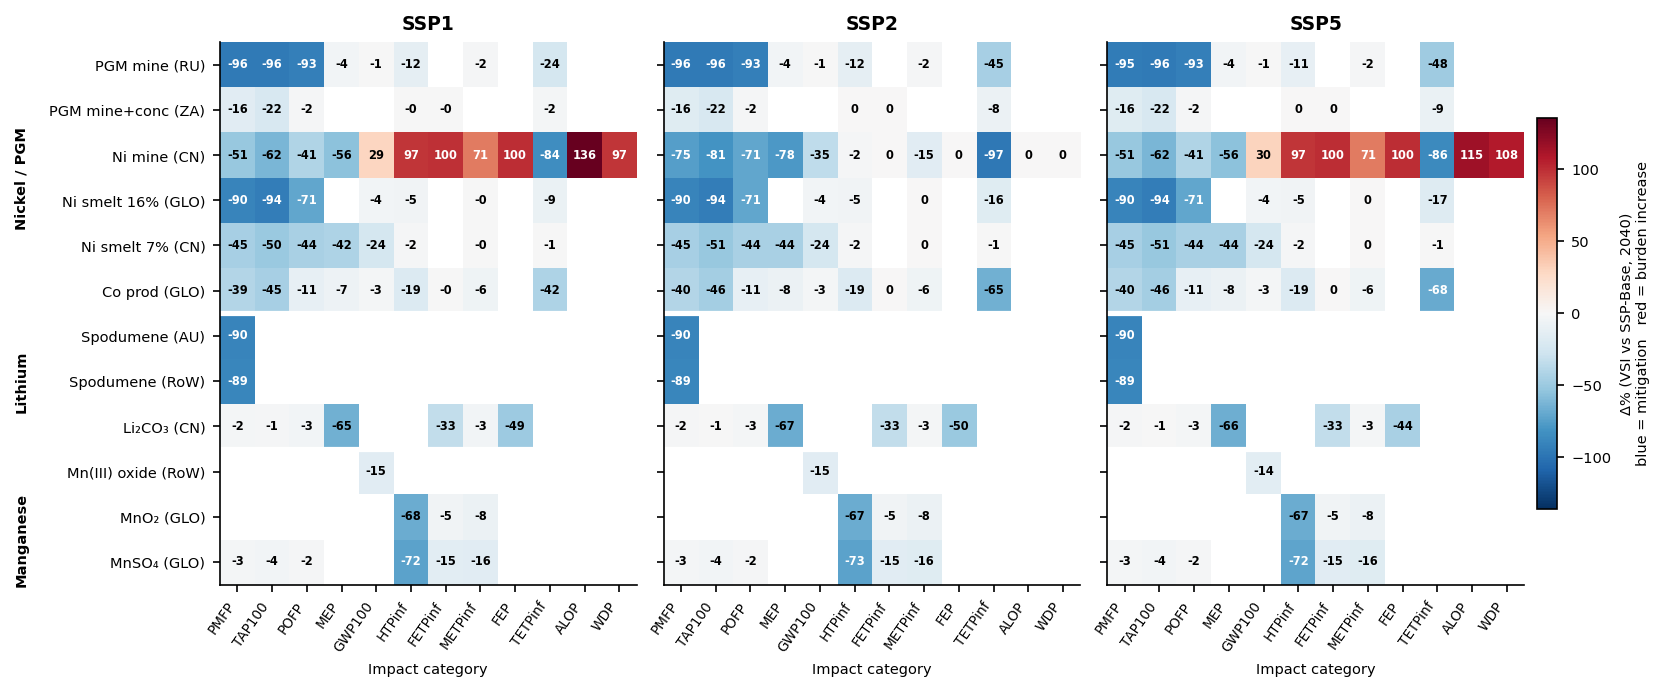

Option A saved.


In [ ]:
import matplotlib.colors as mcolors  # ensure imported

fig, axes = plt.subplots(1, 3, figsize=(11, 4.5), constrained_layout=True)

vabs = df6_all[["SSP1", "SSP2", "SSP5"]].abs().max().max()
norm = mcolors.TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)  # ← FIX 2: was vmax=vabs*0.15
cmap = "RdBu_r"

for ax, ssp in zip(axes, ["SSP1", "SSP2", "SSP5"]):
    mat = pd.DataFrame(index=ACT_ORDER, columns=IMPACT_SHOW, dtype=float).fillna(np.nan)
    for _, row in df6_all.iterrows():
        a, ic = row["activity_short"], row["impact"]
        if a in ACT_ORDER and ic in IMPACT_SHOW:
            mat.loc[a, ic] = row[ssp]

    im = ax.imshow(mat.values.astype(float), cmap=cmap, norm=norm,
                   aspect="auto", interpolation="nearest")
    ax.grid(False)

    for r, act in enumerate(ACT_ORDER):
        for c, ic in enumerate(IMPACT_SHOW):
            val = mat.loc[act, ic]
            if pd.notna(val):
                fg = "white" if abs(val) > vabs * 0.5 else "black"
                ax.text(c, r, f"{val:.0f}", ha="center", va="center",
                        fontsize=5.5, color=fg, fontweight="bold")

    ax.set_xticks(range(len(IMPACT_SHOW)))
    ax.set_xticklabels(IMPACT_SHOW, rotation=55, ha="right", fontsize=6.5)
    ax.set_yticks(range(len(ACT_ORDER)))
    ax.set_yticklabels(ACT_ORDER if ax == axes[0] else [], fontsize=7)
    ax.set_title(ssp, fontweight="bold", fontsize=9)
    ax.set_xlabel("Impact category", fontsize=7)

    for sep_y in [5.5, 8.5]:
        ax.axhline(sep_y, color="white", linewidth=2.5)

for label, y in [("Nickel / PGM", 2.5), ("Lithium", 7.0), ("Manganese", 10.5)]:
    axes[0].text(-6, y, label, ha="right", va="center",        
                 fontsize=7, fontweight="bold", rotation=90,
                 clip_on=False)                                    

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=norm),
    ax=axes, orientation="vertical", fraction=0.015, pad=0.01, shrink=0.8
)
cbar.set_label("\u0394% (VSI vs SSP-Base, 2040)\nblue = mitigation   red = burden increase",
               fontsize=7)

fig.savefig(OUTPUT_DIR / "Figure6_optionA_heatmap.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "Figure6_optionA_heatmap.pdf",           bbox_inches="tight")
plt.show()
print("Figure 6 saved.")


---
## 5. Optional: export as high-res TIFF (journal submission)

In [26]:
# Uncomment and re-run figure cells above, then call:
fig.savefig(OUTPUT_DIR / "Figure4.tiff", dpi=600, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "Figure5.tiff", dpi=600, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "Figure6.tiff", dpi=600, bbox_inches="tight")
print("TIFF export lines above — uncomment and re-run if needed.")

TIFF export lines above — uncomment and re-run if needed.


---
# Sensitivity analysis: technology adoption rate (response to reviewer)

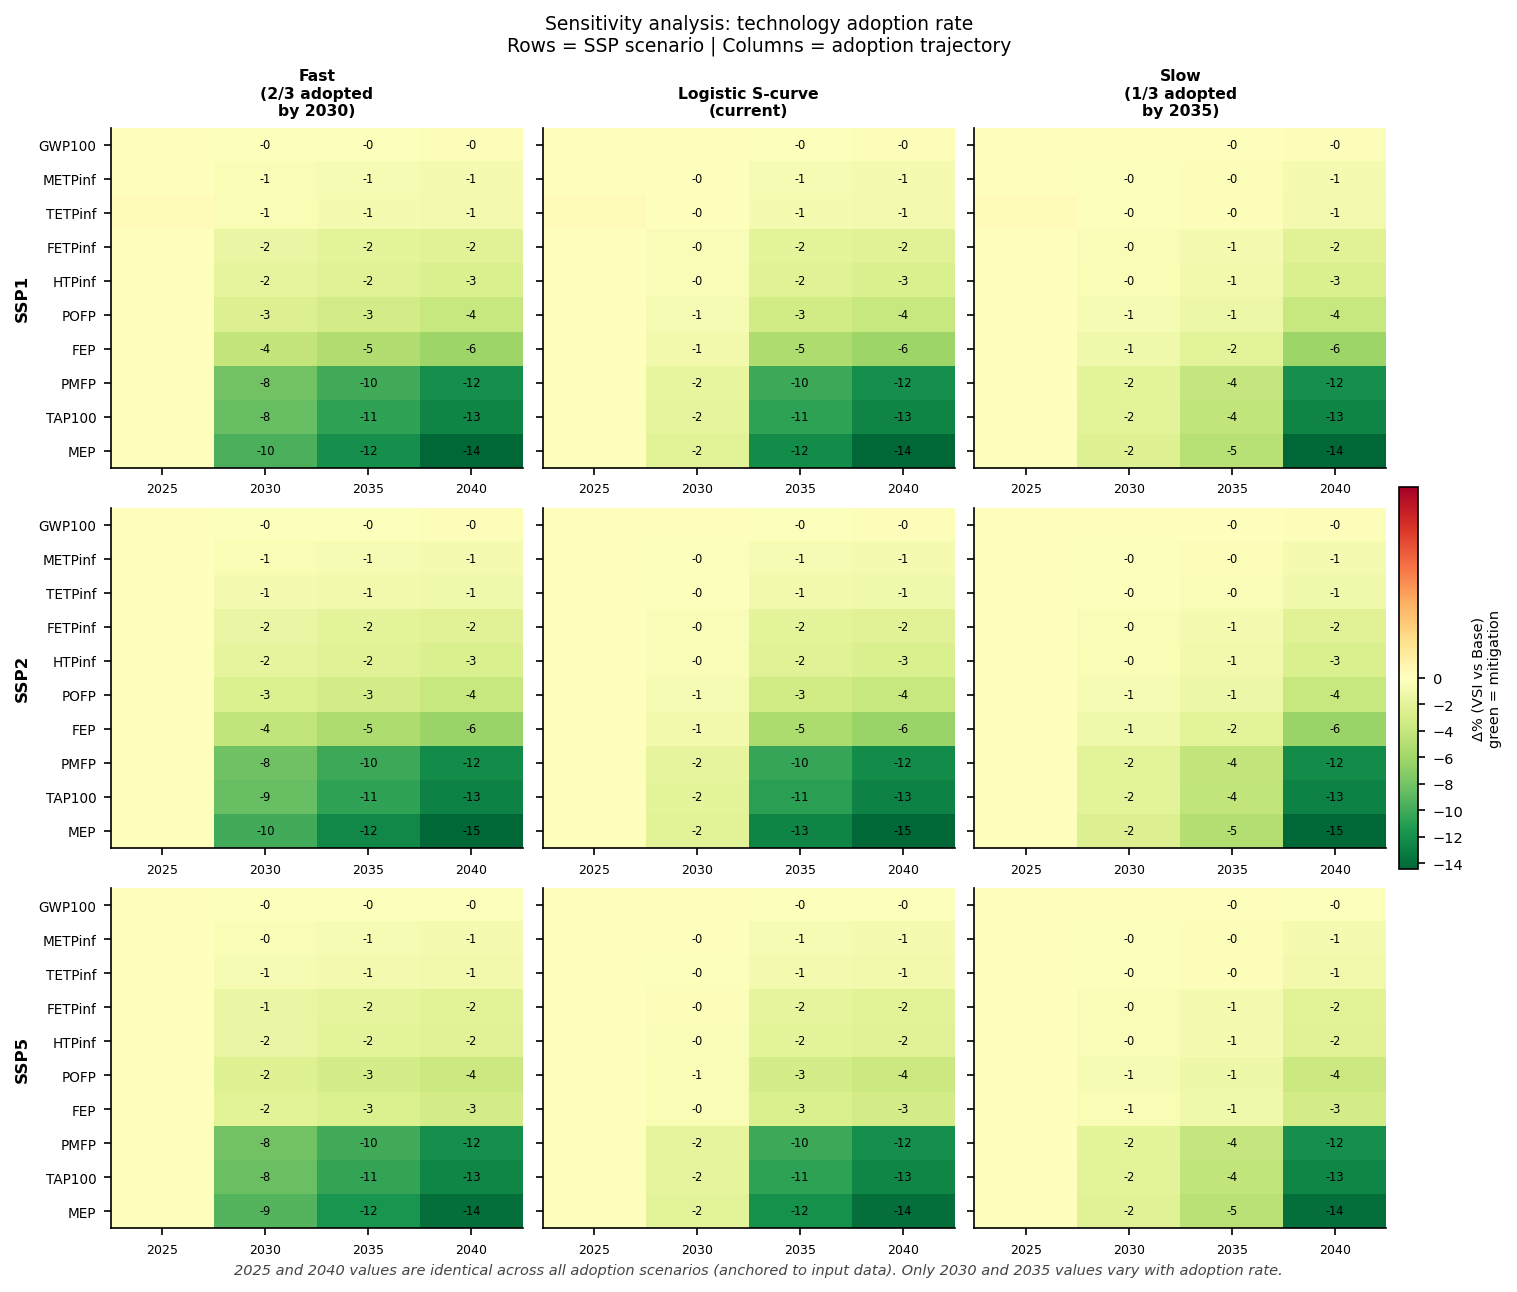

Sensitivity figure saved.


In [33]:
# The logistic adoption curve determines how quickly VSI-aligned mitigation
# builds up between the two anchor years (2025 = no adoption; 2040 = full
# adoption). Since 2025 and 2040 are read directly from input data, the
# adoption rate ONLY affects 2030 and 2035.
#
# Three scenarios are tested, defined by the fraction of total adoption
# achieved at each intermediate year:
#
#   Fast:   2/3 of total delta achieved by 2030, 5/6 by 2035
#   Linear: 1/3 of total delta achieved by 2030, 2/3 by 2035  ← current
#   Slow:   1/6 of total delta achieved by 2030, 1/3 by 2035
#
# These correspond to a logistic curve centred at ~2028 (fast),
# ~2032.5 (linear), and ~2037 (slow) respectively.

ADOPTION_SCENARIOS = {
    "Fast\n(2/3 adopted\nby 2030)":  {2025: 0,   2030: 2/3, 2035: 5/6, 2040: 1},
    "Logistic S-curve\n(current)":   {2025: 0,   2030: 0.15, 2035: 0.85, 2040: 1},
    "Slow\n(1/3 adopted\nby 2035)":  {2025: 0,   2030: 1/6, 2035: 1/3, 2040: 1},
}

# Anchor deltas: confirmed correct from input CSVs
base_sa = df_fig4[df_fig4["Scenario"] == "Base"].set_index(["IAM", "Year"])[VSI_AFFECTED]
vsi_sa  = df_fig4[df_fig4["Scenario"] == "VSI"].set_index(["IAM", "Year"])[VSI_AFFECTED]
d25_sa  = ((vsi - base) / base.abs() * 100).xs(2025, level='Year')
d40_sa  = ((vsi - base) / base.abs() * 100).xs(2040, level='Year')

# Sort categories by 2040 magnitude (most to least mitigation)
cat_order_sa = (d40_sa.abs().mean() * 100).sort_values(ascending=False).index.tolist()
cat_order_sa_rev = cat_order_sa[::-1]

SSPS_SA = ["SSP1", "SSP2", "SSP5"]
YEAR_COLS_SA = [2025, 2030, 2035, 2040]

fig, axes = plt.subplots(3, 3, figsize=(10, 8), constrained_layout=True)

vmax_sa = (d40_sa.abs().mean() * 100).max()
norm_sa = mcolors.TwoSlopeNorm(vmin=-vmax_sa/100, vcenter=0, vmax=vmax_sa/100 * 0.05)
cmap_sa = "RdYlGn_r"

for col_idx, (scen_name, fracs) in enumerate(ADOPTION_SCENARIOS.items()):
    for row_idx, ssp in enumerate(SSPS_SA):
        ax = axes[row_idx, col_idx]

        mat = pd.DataFrame(index=cat_order_sa_rev, columns=YEAR_COLS_SA, dtype=float)
        for yr in YEAR_COLS_SA:
            d_yr = d25_sa.loc[ssp] + (d40_sa.loc[ssp] - d25_sa.loc[ssp]) * fracs[yr]
            for cat in cat_order_sa:
                mat.loc[cat, yr] = d_yr[cat]

        im = ax.imshow(mat.values.astype(float), aspect="auto",
                       cmap=cmap_sa, norm=norm_sa)
        ax.grid(False)

        for r in range(mat.shape[0]):
            for c in range(mat.shape[1]):
                val = mat.values[r, c]
                if abs(val) >= 0.05:
                    fg = "white" if abs(val) > vmax_sa * 0.4 else "black"
                    ax.text(c, r, f"{val:.0f}", ha="center", va="center",
                            fontsize=5.5, color=fg)

        ax.set_xticks(range(4))
        ax.set_xticklabels(YEAR_COLS_SA, fontsize=6)
        ax.set_yticks(range(len(cat_order_sa)))
        ax.set_yticklabels(cat_order_sa_rev if col_idx == 0 else [], fontsize=6.5)
        if col_idx == 0:
            ax.set_ylabel(ssp, fontweight="bold", fontsize=8)
        if row_idx == 0:
            ax.set_title(scen_name, fontweight="bold", fontsize=7.5)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap_sa, norm=norm_sa),
    ax=axes, orientation="vertical", fraction=0.015, pad=0.01, shrink=0.6
)
cbar.set_label("\u0394% (VSI vs Base)\ngreen = mitigation", fontsize=7)

fig.text(0.5, -0.01,
    "2025 and 2040 values are identical across all adoption scenarios (anchored to input data). "
    "Only 2030 and 2035 values vary with adoption rate.",
    ha="center", fontsize=7, style="italic", color="#444")

fig.suptitle(
    "Sensitivity analysis: technology adoption rate\n"
    "Rows = SSP scenario | Columns = adoption trajectory",
    fontsize=9, y=1.04
)

fig.savefig(OUTPUT_DIR / "FigSA1_sensitivity_adoption.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "FigSA1_sensitivity_adoption.pdf",           bbox_inches="tight")
plt.show()
print("Sensitivity figure saved.")